## Ejercicio Python 2: Simulación de inversión periódica (Dollar Cost Averaging)

Aplicar simulaciones para comparar dos estrategias de inversión: aportaciones periódicas frente a inversión única inicial.

 **1. Selecciona un activo financiero y descarga precios históricos de al menos 3 años.**

In [25]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
price = yf.download("B",  start = "2018-01-01")["Close"]
price.head(5)

[*********************100%***********************]  1 of 1 completed


Ticker,B
Date,
2018-01-02,12.603364
2018-01-03,12.437531
2018-01-04,12.462405
2018-01-05,12.396071
2018-01-08,12.221946


**2. Define dos estrategias de inversión con un monto total de $5,000:**

- Inversión única: se invierte todo el monto al inicio del periodo.

- Inversión periódica (DCA): se invierten $100 cada semana hasta completar $5,000.

**3. Simula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).**

In [27]:
# Resampleo a nivel semanal para alinear con las compras semanales del DCA
price_weekly = price.resample('W').last()

In [28]:
price_weekly = price.resample('W').last()

log_returns = np.log(price_weekly / price_weekly.shift(1)).dropna()

mu_weekly = log_returns.mean()
sigma_weekly = log_returns.std()

print("Mean annual return:", mu_weekly * 52 * 100)
print("Annual volatility:", sigma_weekly * np.sqrt(52) * 100)

Mean annual return: Ticker
B    16.918386
dtype: float64
Annual volatility: Ticker
B    36.713398
dtype: float64


Configuramos la simulación

In [29]:
S0 = float(price_weekly.iloc[-1])

num_simulations = 10000
num_weeks = 50

C:\Users\dayan\AppData\Local\Temp\ipykernel_22056\2555097019.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(price_weekly.iloc[-1])


Simulamos las 10,000 trayectorias

In [31]:
mu_weekly = float(log_returns.mean())
sigma_weekly = float(log_returns.std())

C:\Users\dayan\AppData\Local\Temp\ipykernel_22056\987333780.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu_weekly = float(log_returns.mean())
C:\Users\dayan\AppData\Local\Temp\ipykernel_22056\987333780.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_weekly = float(log_returns.std())


In [32]:
np.random.seed(42)

Z = np.random.standard_normal((num_weeks, num_simulations))

prices = np.zeros((num_weeks + 1, num_simulations))
prices[0] = S0

drift = mu_weekly - 0.5 * sigma_weekly**2   # calcular una sola vez

for t in range(1, num_weeks + 1):
    
    shock = sigma_weekly * Z[t-1]
    
    prices[t] = prices[t-1] * np.exp(drift + shock)

**4. Calcula y compara para ambas estrategias:**

Valor final promedio de la inversión.

Desviación estándar del valor final.

Probabilidad de que el valor final sea menor al capital invertido.

In [34]:
weekly_investment = 100

**Estrategia 1:**

In [35]:
initial_investment = weekly_investment * num_weeks

shares_lump = initial_investment / S0

final_lump = shares_lump * prices[-1]

mean_lump = np.mean(final_lump)
std_lump = np.std(final_lump)
prob_loss_lump = np.mean(final_lump < initial_investment)

print("Valor final promedio:", mean_lump)
print("Desviación estándar:", std_lump)
print("Probabilidad de pérdida:", prob_loss_lump)

Valor final promedio: 5867.928693384984
Desviación estándar: 2200.2222999504825
Probabilidad de pérdida: 0.3927


**Estrategia 2:**

In [37]:
shares_dca = np.zeros(num_simulations)

for t in range(num_weeks):
    shares_dca += weekly_investment / prices[t]

final_dca = shares_dca * prices[-1]

total_invested = weekly_investment * num_weeks

mean_dca = np.mean(final_dca)
std_dca = np.std(final_dca)
prob_loss_dca = np.mean(final_dca < total_invested)

print("Valor final promedio:", mean_dca)
print("Desviación estándar:", std_dca)
print("Probabilidad de pérdida:", prob_loss_dca)

Valor final promedio: 5424.37652447986
Desviación estándar: 1195.933274448045
Probabilidad de pérdida: 0.4036


In [38]:
results = pd.DataFrame({
    "Estrategia": ["Lump Sum", "DCA"],
    "Valor Promedio": [mean_lump, mean_dca],
    "Desviación Estándar": [std_lump, std_dca],
    "Probabilidad de Pérdida": [prob_loss_lump, prob_loss_dca]
})

results

,Estrategia,Valor Promedio,Desviación Estándar,Probabilidad de Pérdida
0,Lump Sum,5867.928693,2200.222300,0.3927
1,DCA,5424.376524,1195.933274,0.4036


**5. Construye gráficos:**

Histogramas comparativos de los valores finales.

Evolución promedio de la inversión bajo ambas estrategias.

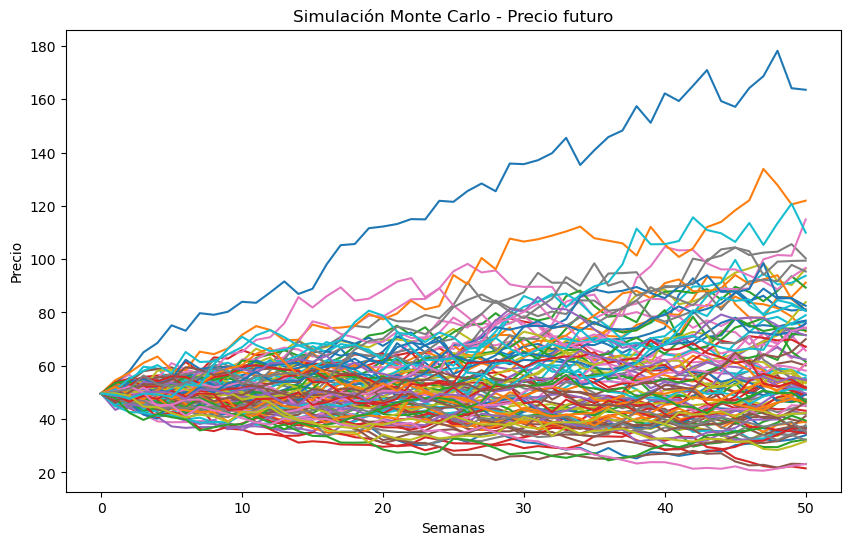

In [33]:
plt.figure(figsize=(10,6))
plt.plot(prices[:, :100])
plt.title("Simulación Monte Carlo - Precio futuro")
plt.xlabel("Semanas")
plt.ylabel("Precio")
plt.show()

**6. Redacta un análisis breve, usando markdown en tu notebook, respondiendo:**

¿En qué condiciones es más ventajosa la inversión periódica?

¿Cuándo es preferible la inversión en un solo momento?

### Breve análisis:

Bajo las condiciones simuladas, la estrategia Lump Sum presenta un mayor valor esperado, consistente con un activo con rendimiento esperado positivo. Sin embargo, exhibe mayor volatilidad y dispersión de resultados.

La estrategia DCA reduce significativamente la variabilidad del valor final, lo que la hace más atractiva en contextos de alta incertidumbre o para inversionistas con mayor aversión al riesgo.

En mercados con tendencia alcista sostenida y horizontes largos, la inversión en un solo momento tiende a ser superior en términos de rendimiento esperado. En cambio, en entornos volátiles o inciertos, la inversión periódica ofrece una mejor gestión del riesgo.